Sky quality metrics: Radiance, MPSAS, Bortle scale ← 昨日「暗さの物差しが要る」って言ってたやつ。Bortleスケールが最初から入ってる。自分で変換しなくていい。
Optional elevation data (NASADEM) ← 昨日「標高は追加候補」って話した、あの標高データまで付いてくる。
Country-based extraction ← 「日本に絞る」がやりたかった、その国別抽出機能がある。
CSV, GeoJSON ← pandas で読める形式。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import json


import geopandas as gpd

In [2]:
#!pip install geopandas


In [3]:
with open('JPN.json') as f:
    data = json.load(f)


In [4]:
#!pip install reverse_geocoder

In [5]:
df = pd.DataFrame(data)
print(f"読み込み完了: {len(df):,} 点")

読み込み完了: 883,497 点


In [6]:
df.head()

,lat,lon,radiance,mpsas,bortle
0,45.552083,129.781252,0.445853,21.600000,2.2
1,45.552083,129.785419,0.512826,21.450001,2.5
2,45.552083,129.789586,0.620681,21.240000,3.0
3,45.552083,129.793752,0.600008,21.280001,2.9
4,45.552083,129.797919,0.501446,21.469999,2.5


In [7]:
df.sort_values('bortle', ascending=True).iloc[[399_999]]

,lat,lon,radiance,mpsas,bortle
422641,36.010416,129.597919,1.262634,20.469999,4.0


In [8]:
df['bortle'].median()   # 中央値がズバリ出る

4.1

In [9]:

df['bortle'].value_counts().sort_index()

bortle
1.0       74
1.1       40
1.2       73
1.3      106
1.4      174
       ...  
7.7     3875
7.8     3685
7.9     3678
8.0     1825
9.0    55546
Name: count, Length: 72, dtype: int64

#### 中央値：4.1
#### bortleが４あれば天の川が見える。
#### まずはbortle1~2のところを観察。

In [10]:
import reverse_geocoder as rg

result = rg.search((44.102083, 145.027086))
print(result)

Loading formatted geocoded file...
[{'lat': '43.65899', 'lon': '145.13197', 'name': 'Shibetsu', 'admin1': 'Hokkaido', 'admin2': '', 'cc': 'JP'}]


In [11]:
# 1. Bortle 2以下に絞る
dark = df[df['bortle'] <= 2].copy()
print(f"Bortle 2以下: {len(dark):,} 点")

# 2. 地名をまとめてつける
coords = list(zip(dark['lat'], dark['lon']))
results = rg.search(coords)
dark['city'] = [r['name'] for r in results]
dark['prefecture'] = [r['admin1'] for r in results]

# 3. どんな都道府県が多いか見る
dark['prefecture'].unique()

Bortle 2以下: 4,983 点


array(['Heilongjiang Sheng', 'Primorskiy', 'Hokkaido', 'Jilin Sheng',
       'Hamgyong-bukto', 'Rason', 'Aomori', 'Akita', 'Iwate', 'Yamagata',
       'Miyagi', 'Niigata', 'Fukushima', 'Ishikawa', 'Tochigi', 'Nagano',
       'Ibaraki', 'Gunma', 'Toyama', 'Shimane', 'Gifu', 'Fukui',
       'Yamanashi', 'Kyoto', 'Hyogo', 'Tottori', 'Shizuoka', 'Okayama',
       'Hiroshima', 'Chiba', 'Yamaguchi', 'Mie', 'Kagawa', 'Wakayama',
       'Ehime', 'Tokushima', 'Fukuoka', 'Oita', 'Nagasaki', 'Kochi',
       'Saga Prefecture', 'Kumamoto', 'Miyazaki', 'Kagoshima'],
      dtype=object)

#### 注意：JPN.jsonはbounding box抽出のため、中国・ロシア・北朝鮮の点が混入。
#### → country code (cc=='JP') で日本のみに絞る必要あり。

In [12]:
dark['country'] = [r['cc'] for r in results]

In [13]:
dark.head()

,lat,lon,radiance,mpsas,bortle,city,prefecture,country
97,45.547916,130.522919,0.418512,21.670000,2.0,Yahe,Heilongjiang Sheng,CN
378,45.535416,132.985419,0.412446,21.680000,2.0,Lesozavodsk,Primorskiy,RU
383,45.535416,134.360419,0.416499,21.670000,2.0,Novopokrovka,Primorskiy,RU
396,45.531250,130.672919,0.402576,21.709999,1.9,Dongxing,Heilongjiang Sheng,CN
460,45.531250,132.752086,0.401932,21.709999,1.9,Lesozavodsk,Primorskiy,RU


In [100]:
dark[dark['prefecture'] == 'Okinawa']

,lat,lon,radiance,mpsas,bortle,city,prefecture,country


In [14]:
dark_jp = dark[dark['country'] == 'JP'].copy()
print(f"日本のみ: {len(dark_jp):,} 点")
dark_jp['prefecture'].unique()

日本のみ: 4,268 点


array(['Hokkaido', 'Aomori', 'Akita', 'Iwate', 'Yamagata', 'Miyagi',
       'Niigata', 'Fukushima', 'Ishikawa', 'Tochigi', 'Nagano', 'Ibaraki',
       'Gunma', 'Toyama', 'Shimane', 'Gifu', 'Fukui', 'Yamanashi',
       'Kyoto', 'Hyogo', 'Tottori', 'Shizuoka', 'Okayama', 'Hiroshima',
       'Chiba', 'Yamaguchi', 'Mie', 'Kagawa', 'Wakayama', 'Ehime',
       'Tokushima', 'Fukuoka', 'Oita', 'Nagasaki', 'Kochi',
       'Saga Prefecture', 'Kumamoto', 'Miyazaki', 'Kagoshima'],
      dtype=object)

In [15]:
dark_jp['prefecture'].nunique()

39

In [16]:
dark_jp['city'].unique()

array(['Makubetsu', 'Rishiri Town', 'Wakkanai', 'Nayoro', 'Rumoi',
       'Mombetsu', 'Otrada', 'Kitami', 'Abashiri', 'Shibetsu', 'Bihoro',
       'Kamikawa', 'Ishikari', 'Otofuke', 'Yoichi', 'Iwanai', 'Nemuro',
       'Kushiro', 'Shimo-furano', 'Otaru', 'Obihiro', 'Niseko Town',
       'Date', 'Shiraoi', 'Muroran', 'Shizunai-furukawacho', 'Kamiiso',
       'Nanae', 'Hakodate', 'Mutsu', 'Shimokizukuri', 'Goshogawara',
       'Aomori Shi', 'Inuotose', 'Noshiromachi', 'Furudate', 'Hirosaki',
       'Hanawa', 'Odate', 'Takanosu', 'Hachinohe', 'Ichinohe', 'Miyako',
       'Tenno', 'Shizukuishi', 'Kakunodatemachi', 'Tono', 'Akita',
       'Yamada', 'Akita Shi', 'Otsuchi', 'Kamaishi', 'Yuza', 'Omagari',
       'Sakata', 'Yuzawa', 'Ofunato', 'Mizusawa', 'Ichinoseki', 'Shinjo',
       'Furukawa', 'Obanazawa', 'Onagawa Cho', 'Tsuruoka', 'Murakami',
       'Sagae', 'Nagai', 'Ryotsu-minato', 'Inawashiro', 'Nihommatsu',
       'Kitakata', 'Namie', 'Muramatsu', 'Funehikimachi-funehiki',
       'Nag

In [17]:
dark_jp.head()

,lat,lon,radiance,mpsas,bortle,city,prefecture,country
482,45.531250,141.952086,0.408587,21.700001,2.0,Makubetsu,Hokkaido,JP
570,45.527083,141.918753,0.408402,21.700001,2.0,Makubetsu,Hokkaido,JP
1441,45.493750,141.868753,0.399477,21.719999,1.9,Makubetsu,Hokkaido,JP
1547,45.489583,141.868753,0.386844,21.750000,1.7,Makubetsu,Hokkaido,JP
1642,45.485416,141.868753,0.367310,21.809999,1.4,Makubetsu,Hokkaido,JP


<Axes: >

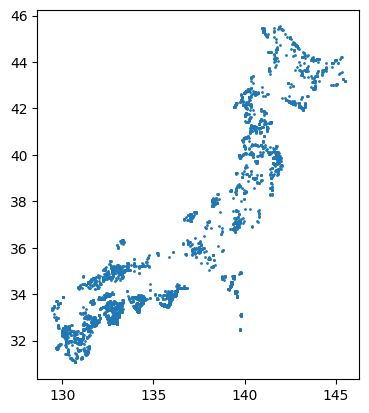

In [18]:
# lat/lon から geometry(点)を作って、GeoDataFrameにする
gdf = gpd.GeoDataFrame(
    dark_jp,
    geometry=gpd.points_from_xy(dark_jp['lon'], dark_jp['lat']),
    crs="EPSG:4326"   # ← 緯度経度の座標系のおまじない
)

# とりあえず点を描いてみる
gdf.plot(markersize=1)

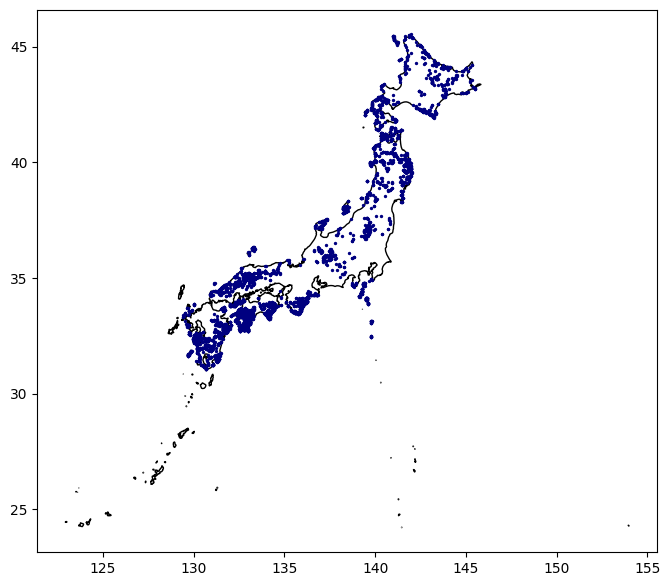

In [19]:
# 世界の地図データを取得(GeoPandas内蔵 or ネットから)
world = gpd.read_file("https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip")
japan = world[world['NAME'] == 'Japan']

# 重ねて描く
fig, ax = plt.subplots(figsize=(8, 10))
japan.plot(ax=ax, color='white', edgecolor='black')   # 下:白地図
gdf.plot(ax=ax, markersize=2, color='navy')            # 上:暗い点
plt.show()

#### 西日本位はかなりポイントがある。→大阪、京都からのアクセスは良いだろう。
#### 東京から近いと言う観点だと、群馬栃木あたり？
#### 東京一点集中から視点をずらせるかもしれない。
###  この辺りで気象データの観察に移行したい。

In [20]:
weather = pd.read_csv('sunshine-atlas-monthly-climate.csv')
weather.head()

,iata,city,country_code,month,sunshine_score,day_high_c,night_low_c,rain_mm,midday_uv_index,sea_temp_c
0,ADD,Addis Ababa,ET,Jan,95,24,7,12,12,NaN
1,ADD,Addis Ababa,ET,Feb,92,25,9,27,13,NaN
2,ADD,Addis Ababa,ET,Mar,87,25,10,56,13,NaN
3,ADD,Addis Ababa,ET,Apr,81,25,11,90,13,NaN
4,ADD,Addis Ababa,ET,May,81,25,12,89,12,NaN


In [21]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45996 entries, 0 to 45995
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iata             45996 non-null  object 
 1   city             45996 non-null  object 
 2   country_code     45900 non-null  object 
 3   month            45996 non-null  object 
 4   sunshine_score   45996 non-null  int64  
 5   day_high_c       45996 non-null  int64  
 6   night_low_c      45996 non-null  int64  
 7   rain_mm          45996 non-null  int64  
 8   midday_uv_index  45996 non-null  int64  
 9   sea_temp_c       18924 non-null  float64
dtypes: float64(1), int64(5), object(4)
memory usage: 3.5+ MB


In [22]:
weather.country_code.unique()

array(['ET', 'NZ', 'NL', 'GR', 'US', 'AE', 'ES', 'DE', 'TH', 'IN', 'AU',
       'CO', 'BE', 'EG', 'CN', 'FR', 'MA', 'DK', 'MX', 'QA', 'IE', 'GB',
       'AR', 'IT', 'BR', 'VN', 'FI', 'HK', 'JP', 'KR', 'TR', 'SA', 'ZA',
       'IS', 'MY', 'PE', 'PH', 'NO', 'PA', 'DO', 'CL', 'SG', 'RU', 'TW',
       'AT', 'PL', 'CA', 'CH', 'CI', 'NG', 'GH', 'KZ', 'DZ', 'JO', 'AG',
       'SE', 'AW', 'BH', 'RS', 'LB', 'BB', 'IQ', 'BG', 'KG', 'SK', 'HU',
       'BZ', 'VE', 'ID', 'RO', 'LK', 'BD', 'SY', 'TZ', 'HR', 'TN', 'SN',
       'TJ', 'UG', 'AM', 'PT', 'CD', 'KY', 'GT', 'AZ', 'CU', 'IR', 'PK',
       'JE', 'KH', 'NP', 'LT', 'GE', 'KW', 'CY', 'CR', 'SI', 'LU', 'JM',
       'OM', 'MO', 'MT', 'MV', 'MU', 'BY', 'FJ', 'BS', 'AO', 'KE', 'TC',
       'PG', 'TT', 'PF', 'CZ', 'XK', 'MM', 'LV', 'MD', 'SV', 'CV', 'BA',
       'PR', 'MK', 'SX', 'UZ', 'ME', 'AL', 'EE', 'IL', 'MN', 'EC', 'LA',
       'YE', 'TM', 'PY', 'BM', 'GM', 'ML', 'BQ', 'BN', 'CG', 'HT', 'GF',
       'BO', 'GN', 'BJ', 'CW', 'CM', 'DM', 'YT', 'F

In [23]:
weather_jp = weather[weather['country_code'] == 'JP']
weather_jp.head()

,iata,city,country_code,month,sunshine_score,day_high_c,night_low_c,rain_mm,midday_uv_index,sea_temp_c
468,HND,Tokyo,JP,Jan,6,9,1,80,2,10.0
469,HND,Tokyo,JP,Feb,13,10,1,75,3,11.0
470,HND,Tokyo,JP,Mar,34,14,4,124,4,12.0
471,HND,Tokyo,JP,Apr,54,18,9,135,5,15.0
472,HND,Tokyo,JP,May,63,23,14,148,6,19.0


In [24]:
weather_jp['city'].nunique()   # 日本の都市が何個あるか

78

In [25]:
weather_jp['city'].unique()    # どの都市か一覧

array(['Tokyo', 'Osaka', 'Sapporo', 'Fukuoka', 'Nagoya', 'Naha',
       'Asahikawa', 'Aomori', 'Amami', 'Akita', 'Shizuoka', 'Yamagata',
       'Hiroshima', 'Hakodate', 'Hanamaki', 'Saga', 'Ibaraki', 'Ishigaki',
       'Iwakuni', 'Izumo', 'Kochi (Japan)', 'Niigata', 'Kitakyushu',
       'Miyazaki', 'Kumamoto', 'Kanazawa', 'Kagoshima', 'Kushiro',
       'Kitami', 'Miyakojima', 'Misawa', 'Matsuyama', 'Nagasaki',
       'Obihiro', 'Oita', 'Okayama', 'Sendai', 'Shonai', 'Takamatsu',
       'Tokushima', 'Toyama', 'Tottori', 'Ube', 'Kobe', 'Yonago', 'Aguni',
       'Amakusa', 'Fukushima', 'Goto', 'Hachijojima', 'Iki', 'Masuda',
       'Kikai', 'Kitadaitōjima', 'Yakushima', 'Monbetsu', 'Minamidaito',
       'Matsumoto', 'Miyakejima', 'Wajima', 'Yonaguni', 'Izu Oshima',
       'Okushiri', 'Wadomari', 'Okinoshima', 'Ōdate', 'Rishiri', 'Yoron',
       'Sado', 'Nakashibetsu', 'Shirahama', 'Toyooka', 'Amagi',
       'Tanegashima', 'Tarama', 'Tsushima', 'Kumejima', 'Wakkanai'],
      dtype=object)

### 「星の見えやすさ」の要因(inferenceの種)
- コア: 光害(暗さ)× 日照時間(晴れ)
- 追加候補: 湿度(空気の澄み具合)← 気温より直接的
         気温(低い→乾燥、の間接経路)← 勘で気になった
         標高(高い→靄が少ない)
- 面白い問い: これらを足すと、暗い×晴れだけの時とランキングが変わる?
  → 「何が星空を決めるか」= inference型の深掘り

### 項目 確定(5つ)+ 役割分け
【分析用】星スコアの材料
- 光害(持ってる) / 日平均雲量 / 天気概況(夜) / 日平均相対湿度
【表示用】パンフレットに添える(スコアには使わない)
- 日平均気温 → 防寒の参考(UX)
- 日照時間 → 昼の晴れ参考(※日の出時刻は出せない)
※日の出/入り時刻が欲しい → 緯度経度+日付から計算(astralライブラリ)。気象データ不要。
※雲量・天気概況は「官署のみ」→ 田舎で欠測の恐れ。試しに落として確認。

In [26]:
import requests

# 国土地理院のリバースジオコーディングAPI(緯度経度→日本語住所)
def get_jp_address(lat, lon):
    url = "https://mreversegeocoder.gsi.go.jp/reverse-geocoder/LonLatToAddress"
    params = {"lat": lat, "lon": lon}
    try:
        r = requests.get(url, params=params, timeout=10)
        data = r.json()
        return data['results']['muniCd'], data['results']['lv01Nm']  # 市区町村コードと名前
    except Exception as e:
        return None, str(e)

# まず1点だけ試す(北海道の暗い点)
print(get_jp_address(44.102083, 145.027086))

('01545', '大字遠音別村')


### 🎯 プロジェクト設計

■ 手元にあるデータ(2つ):
  1. JPN.json … 光害データ(緯度経度 + Bortle暗さ)88万点 → 暗いスポット233地点に絞り済み
  2. jma_station_active.csv … 気象観測所マスタ 約1286地点
     - 地点コード / 日本語名 / 緯度経度 / 観測項目フラグ / 稼働期間

■ これから取るデータ:
  3. 気象庁から、選んだ観測所の「晴れやすさ(日照時間・湿度など)」平年値

■ 組み立て(次回やること):
  - Step1: station_active.csv を、日照時間を観測してる地点だけにフィルタ
         (Sunshine Duration==1 かつ End Date==9999-99-99)
  - Step2: 各光害スポットに、緯度経度が"一番近い"観測所を割り当て(最近傍=KNN的)
  - Step3: その観測所リストで、気象庁から晴天データを取得(手動DL)
  - Step4: 光害スポット + 暗さ + 最寄り観測所の天気 を結合
  - Step5: 地図に「星が見えるスポット」を表示(暗さ×晴れやすさ)

■ 「近い」の定義 = 緯度だけでなく緯度経度の2次元距離(名古屋/豊橋を取り違えない)

In [27]:
active_station_df = pd.read_csv('jma_station_active.csv')
active_station_df.head()

,Station Number,Station Name(Kanji),Station Name(Kana),Station Name,Station Name of Snow(Kanji),Station Name of Snow(Kana),Station Name of Snow,Latitude_Precipitation(degree),Longitude_Precipitation(degree),Altitude_Precipitation(m),...,Humidity,Start Date,End Date,Old Station Number,Disconnection of Precipitation,Disconnection of Wind Speed,Disconnection of Temperature,Disconnection of Sunshine Duration,Disconnection of Depth of Snow Cover,Disconnection of Humidity
0,11001,宗谷岬,ソウヤミサキ,SOYAMISAKI,NaN,NaN,NaN,45.520,141.935,26,...,1,2021-03-18,9999-99-99,11001,0,0,0,0,0,0
1,11016,稚内,ワッカナイ,WAKKANAI,稚内,ワッカナイ,WAKKANAI,45.415,141.678,3,...,1,2021-03-11,9999-99-99,11016,0,0,0,0,0,0
2,11046,礼文,レブン,REBUN,NaN,NaN,NaN,45.305,141.045,65,...,1,2021-10-26,9999-99-99,11046,0,0,0,0,0,0
3,11061,声問,コエトイ,KOETOI,声問,コエトイ,KOETOI,45.403,141.802,8,...,0,2017-11-09,9999-99-99,11061,0,0,0,0,0,0
4,11076,浜鬼志別,ハマオニシベツ,HAMAONISHIBETSU,浜鬼志別,ハマオニシベツ,HAMAONISHIBETSU,45.335,142.170,13,...,1,2023-09-19,9999-99-99,11076,0,0,0,0,0,0


In [28]:
station_history_df = pd.read_csv('jma_station.csv')

In [29]:
#station_history_df[['Temperature']].sum()

In [30]:
active_station_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Station Number                        1286 non-null   int64  
 1   Station Name(Kanji)                   1286 non-null   object 
 2   Station Name(Kana)                    1286 non-null   object 
 3   Station Name                          1286 non-null   object 
 4   Station Name of Snow(Kanji)           334 non-null    object 
 5   Station Name of Snow(Kana)            334 non-null    object 
 6   Station Name of Snow                  334 non-null    object 
 7   Latitude_Precipitation(degree)        1286 non-null   float64
 8   Longitude_Precipitation(degree)       1286 non-null   float64
 9   Altitude_Precipitation(m)             1286 non-null   int64  
 10  Height of Anemometer(m)               915 non-null    float64
 11  Latitude_Snow(deg

historyは要らなそう

In [31]:
# 各項目を"観測してる"地点が何個あるか(フラグ=1の数)
print("日照時間:", (active_station_df['Sunshine Duration'] == 1).sum(), "地点")
print("湿度:", (active_station_df['Humidity'] == 1).sum(), "地点")
print("降水量:", (active_station_df['Precipitation'] == 1), "地点")

日照時間: 155 地点
湿度: 589 地点
降水量: 0       True
1       True
2       True
3       True
4       True
        ... 
1281    True
1282    True
1283    True
1284    True
1285    True
Name: Precipitation, Length: 1286, dtype: bool 地点


In [32]:
active_station_df[active_station_df['Precipitation'] == 0]

,Station Number,Station Name(Kanji),Station Name(Kana),Station Name,Station Name of Snow(Kanji),Station Name of Snow(Kana),Station Name of Snow,Latitude_Precipitation(degree),Longitude_Precipitation(degree),Altitude_Precipitation(m),...,Humidity,Start Date,End Date,Old Station Number,Disconnection of Precipitation,Disconnection of Wind Speed,Disconnection of Temperature,Disconnection of Sunshine Duration,Disconnection of Depth of Snow Cover,Disconnection of Humidity
614,50066,富士山,フジサン,FUJISAN,NaN,NaN,NaN,35.36,138.727,3775,...,1,2021-03-02,9999-99-99,50066,0,0,0,0,0,0


In [33]:
zero_humidity = active_station_df[active_station_df['Humidity'] == 0]

In [34]:
one_humidity =active_station_df[active_station_df['Humidity'] == 1]

/Users/kanon/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28287 (\N{CJK UNIFIED IDEOGRAPH-6E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kanon/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kanon/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kanon/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


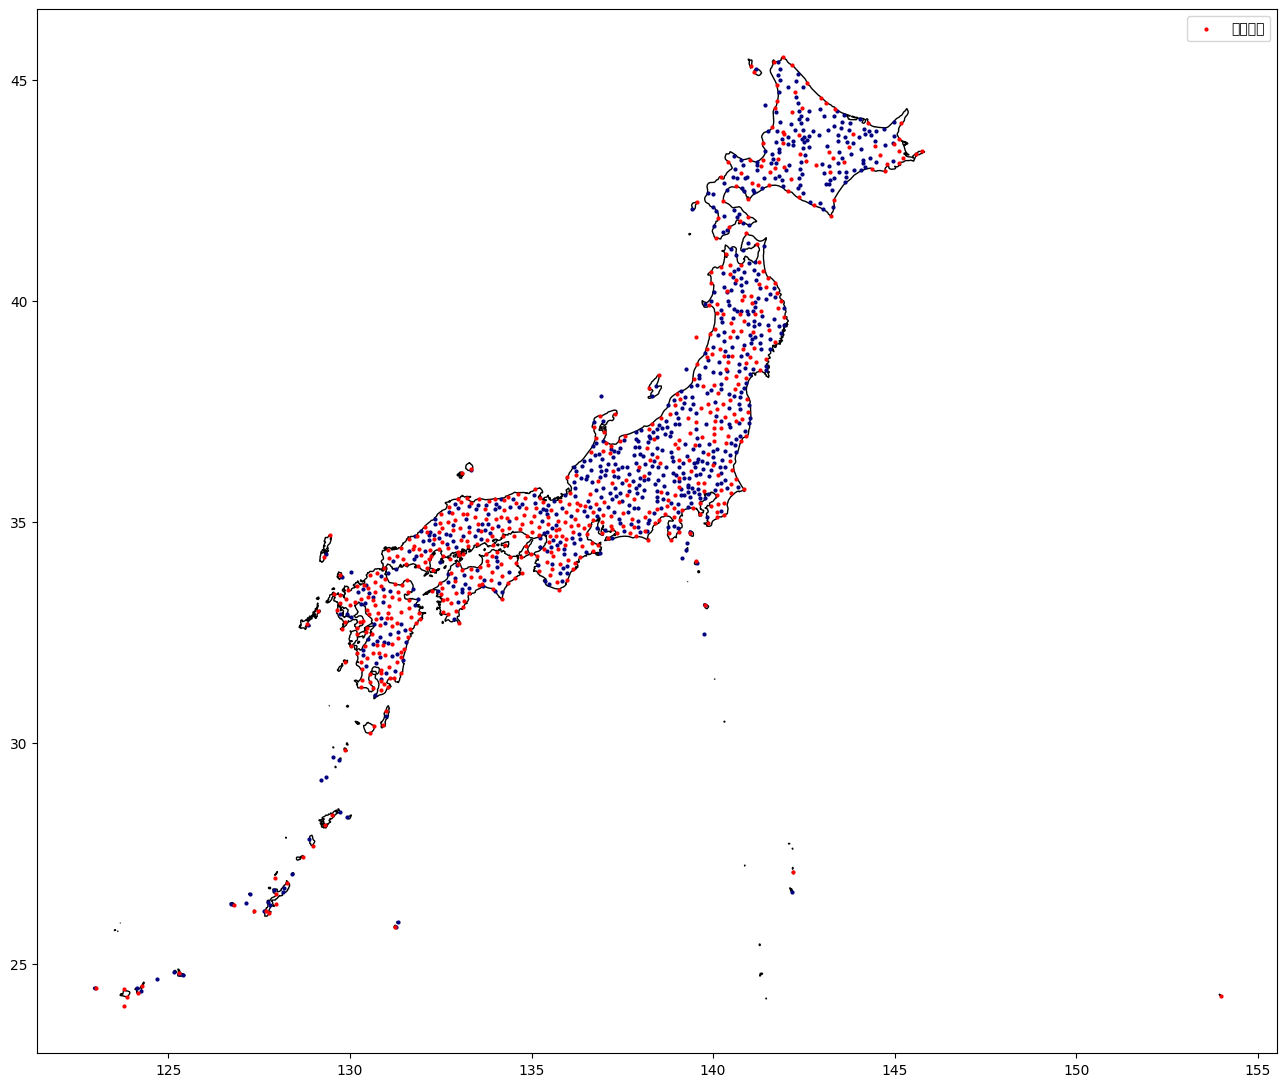

In [35]:
gdf_hum = gpd.GeoDataFrame(
    zero_humidity,
    geometry=gpd.points_from_xy(zero_humidity['Longitude_Precipitation(degree)'], zero_humidity['Latitude_Precipitation(degree)']),
    crs="EPSG:4326"   # ← 緯度経度の座標系のおまじない
)

fig, ax = plt.subplots(figsize=(16, 20))
japan.plot(ax=ax, color='white', edgecolor='black')   # 下:白地図
gdf_hum.plot(ax=ax, markersize=4, color='navy')            # 上:暗い点

gdf_hum_one = gpd.GeoDataFrame(
    one_humidity,
    geometry=gpd.points_from_xy(one_humidity['Longitude_Precipitation(degree)'],
                                one_humidity['Latitude_Precipitation(degree)']),
    crs="EPSG:4326"
)
gdf_hum_one.plot(ax=ax, markersize=4, color='red', label='湿度あり')

plt.legend()
plt.show()

In [36]:
zero_sunshine = active_station_df[active_station_df['Sunshine Duration'] == 0]

In [37]:
one_sunshine = active_station_df[active_station_df['Sunshine Duration'] == 1]

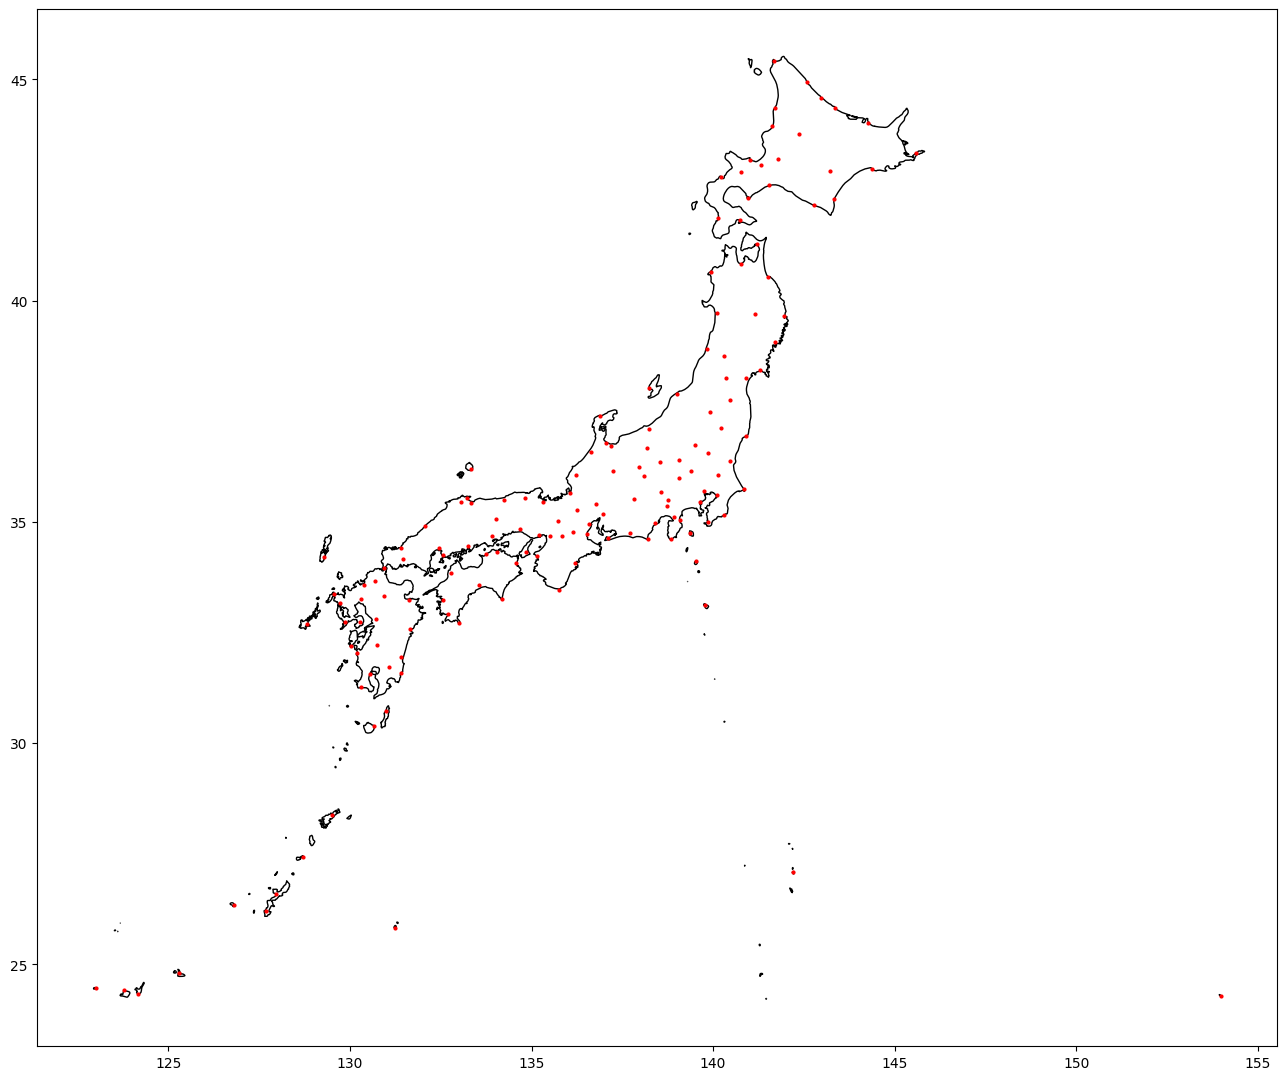

In [38]:
gdf_sun_zero = gpd.GeoDataFrame(
    zero_sunshine,
    geometry=gpd.points_from_xy(zero_sunshine['Longitude_Precipitation(degree)'], zero_sunshine['Latitude_Precipitation(degree)']),
    crs="EPSG:4326"   # ← 緯度経度の座標系のおまじない
)

fig, ax = plt.subplots(figsize=(16, 20))
japan.plot(ax=ax, color='white', edgecolor='black')   # 下:白地図
#gdf_sun_zero.plot(ax=ax, markersize=4, color='navy')            # 上:暗い点

gdf_sun_one = gpd.GeoDataFrame(
    one_sunshine,
    geometry=gpd.points_from_xy(one_sunshine['Longitude_Precipitation(degree)'],
                                one_sunshine['Latitude_Precipitation(degree)']),
    crs="EPSG:4326"
)
gdf_sun_one.plot(ax=ax, markersize=4, color='red')

plt.show()

### 天気項目
- 日照時間155 → 地図で都市偏在を確認。hidden gemに無い → 不採用
- 湿度589 → 西日本中心にそこそこ分布 → 補助として採用
- 降水量1285 → ほぼ全国 → 主役として採用
→ proxy: 晴れやすさ ≒ 降水量の少なさ(+湿度)

In [39]:
sample = dark_jp.sample(n=10, random_state=42)
sample

,lat,lon,radiance,mpsas,bortle,city,prefecture,country
570087,35.147916,134.202086,0.418828,21.670000,2.0,Tsuyama,Okayama,JP
224389,38.968750,140.543753,0.394916,21.730000,1.8,Yuzawa,Akita,JP
118008,42.989583,144.727086,0.413512,21.680000,2.0,Kushiro,Hokkaido,JP
285524,37.456250,137.060419,0.409762,21.690001,2.0,Nanao,Ishikawa,JP
774045,33.797916,136.002086,0.387214,21.750000,1.7,Shingu,Wakayama,JP
845504,32.806250,132.977086,0.327015,21.940001,1.0,Nakamura,Kochi,JP
805255,33.389583,132.752086,0.383623,21.760000,1.6,Kihoku-cho,Ehime,JP
846926,32.781250,132.872919,0.370451,21.799999,1.4,Sukumo,Kochi,JP
305490,37.068750,139.477086,0.385143,21.760000,1.7,Nikko,Tochigi,JP
780162,33.697916,131.589586,0.387115,21.750000,1.7,Bungo-Takada-shi,Oita,JP


In [40]:
sample_weather = pd.read_csv('sample_jma_data.csv', encoding='shift_jis',
                              header=[1,2])   # 2行目=地点名, 3行目=項目名を列名にsample_weather = pd.read_csv('sample_jma_data.csv', encoding='shift_jis')
sample_weather.head()

Unnamed: 0_level_0      釧路                                              \
                 年月日 平均湿度(％) 平均湿度(％).1 平均湿度(％).2 降水量の合計(mm) 降水量の合計(mm).1   
0                NaN     NaN      品質情報      均質番号        NaN       現象なし情報   
1           2023/1/1    64.0         8         1        0.0            1   
2           2023/1/2    52.0         8         1        0.0            1   
3           2023/1/3    60.0         8         1        0.0            1   
4           2023/1/4    63.0         8         1        0.0            1   

                                               ...        中村    豊後高田  \
  降水量の合計(mm).2 降水量の合計(mm).3 平均気温(℃) 平均気温(℃).1  ... 平均気温(℃).2 平均湿度(％)   
0         品質情報         均質番号     NaN      品質情報  ...      均質番号     NaN   
1            8            1    -3.5         8  ...         1     NaN   
2            8            1    -5.7         8  ...         1     NaN   
3            8            1    -9.6         8  ...         1     NaN   
4            8            1   -10.1         8  ...         1     NaN   

                                                                              \
  平均湿度(％).1 平均湿度(％).2 降水量の合計(mm) 降水量の合計(mm).1 降水量の合計(mm).2 平均気温(℃) 平均気温(℃).1   
0      品質情報      均質番号        NaN         品質情報         均質番号     NaN      品質情報   
1         0         1        0.0            8            1     6.4         8   
2         0         1        0.0            8            1     6.4         8   
3         0         1        0.0            8            1     4.1         8   
4         0         1        0.0            8            1     5.4         8   

             
  平均気温(℃).2  
0      均質番号  
1         1  
2         1  
3         1  
4         1  

[5 rows x 95 columns]

In [41]:
sample_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 95 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   (Unnamed: 0_level_0, 年月日)  1066 non-null   object 
 1   (釧路, 平均湿度(％))              1066 non-null   float64
 2   (釧路, 平均湿度(％).1)            1067 non-null   object 
 3   (釧路, 平均湿度(％).2)            1067 non-null   object 
 4   (釧路, 降水量の合計(mm))           1066 non-null   float64
 5   (釧路, 降水量の合計(mm).1)         1067 non-null   object 
 6   (釧路, 降水量の合計(mm).2)         1067 non-null   object 
 7   (釧路, 降水量の合計(mm).3)         1067 non-null   object 
 8   (釧路, 平均気温(℃))              1066 non-null   float64
 9   (釧路, 平均気温(℃).1)            1067 non-null   object 
 10  (釧路, 平均気温(℃).2)            1067 non-null   object 
 11  (湯沢, 平均湿度(％))              793 non-null    float64
 12  (湯沢, 平均湿度(％).1)            1067 non-null   object 
 13  (湯沢, 平均湿度(％).2)            1067 non-null   objec

In [42]:
# 最初の数行(説明・ヘッダー)を飛ばして、データ部分だけ読む
sample_weather = pd.read_csv('sample_jma_data.csv', encoding='shift_jis',
                              skiprows=5, header=None)
sample_weather.head()

,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,91,92,93,94
0,2023/1/1,64,8,1,0.0,1,8,1,-3.5,8,...,1,NaN,0,1,0.0,8,1,6.4,8,1
1,2023/1/2,52,8,1,0.0,1,8,1,-5.7,8,...,1,NaN,0,1,0.0,8,1,6.4,8,1
2,2023/1/3,60,8,1,0.0,1,8,1,-9.6,8,...,1,NaN,0,1,0.0,8,1,4.1,8,1
3,2023/1/4,63,8,1,0.0,1,8,1,-10.1,8,...,1,NaN,0,1,0.0,8,1,5.4,8,1
4,2023/1/5,62,8,1,0.0,1,8,1,-7.8,8,...,1,NaN,0,1,0.0,8,1,4.4,8,1


In [43]:
# ファイルの最初の8行を、そのまま表示して構造を見る
with open('sample_jma_data.csv', encoding='shift_jis') as f:
    for i, line in enumerate(f):
        if i < 8:
            print(i, ':', line.strip())

0 : ダウンロードした時刻：2026/08/16 12:12:58
1 : 
2 : ,釧路,釧路,釧路,釧路,釧路,釧路,釧路,釧路,釧路,釧路,湯沢,湯沢,湯沢,湯沢,湯沢,湯沢,湯沢,湯沢,湯沢,奥日光（日光）,奥日光（日光）,奥日光（日光）,奥日光（日光）,奥日光（日光）,奥日光（日光）,奥日光（日光）,奥日光（日光）,奥日光（日光）,奥日光（日光）,七尾,七尾,七尾,七尾,七尾,七尾,七尾,七尾,七尾,新宮,新宮,新宮,新宮,新宮,新宮,新宮,新宮,新宮,津山,津山,津山,津山,津山,津山,津山,津山,津山,津山,近永,近永,近永,近永,近永,近永,近永,近永,近永,宿毛,宿毛,宿毛,宿毛,宿毛,宿毛,宿毛,宿毛,宿毛,宿毛,中村,中村,中村,中村,中村,中村,中村,中村,中村,豊後高田,豊後高田,豊後高田,豊後高田,豊後高田,豊後高田,豊後高田,豊後高田,豊後高田
3 : 年月日,平均湿度(％),平均湿度(％),平均湿度(％),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),平均気温(℃),平均気温(℃),平均気温(℃),平均湿度(％),平均湿度(％),平均湿度(％),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),平均気温(℃),平均気温(℃),平均気温(℃),平均湿度(％),平均湿度(％),平均湿度(％),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),平均気温(℃),平均気温(℃),平均気温(℃),平均湿度(％),平均湿度(％),平均湿度(％),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),平均気温(℃),平均気温(℃),平均気温(℃),平均湿度(％),平均湿度(％),平均湿度(％),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),平均気温(℃),平均気温(℃),平均気温(℃),平均湿度(％),平均湿度(％),平均湿度(％),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),平均気温(℃),平均気温(℃),平均気温(℃),平均湿度(％),平均湿度(％),平均湿度(％),降水量の合計(mm),降水量の合計(mm),降水量の合計(mm),平均気温(℃),平均気温(℃),平均気温(

In [44]:
sample_weather_monthly = pd.read_csv('sample_jma_month_data.csv',encoding='shift_jis', header=[1,2])
sample_weather_monthly.drop(0, inplace=True)

In [45]:
sample_weather_monthly.head()

Unnamed: 0_level_0      釧路                                              \
                  年月 平均湿度(％) 平均湿度(％).1 平均湿度(％).2 降水量の合計(mm) 降水量の合計(mm).1   
1             2005/1    65.0         8         1       11.5            0   
2             2005/2    64.0         8         1       26.5            0   
3             2005/3    66.0         8         1       75.5            0   
4             2005/4    71.0         8         1       99.5            0   
5             2005/5    78.0         8         1      103.5            0   

                                               ...        中村    豊後高田  \
  降水量の合計(mm).2 降水量の合計(mm).3 平均気温(℃) 平均気温(℃).1  ... 平均気温(℃).2 平均湿度(％)   
1            8            1    -4.3         8  ...         1     NaN   
2            8            1    -4.9         8  ...         1     NaN   
3            8            1    -1.0         8  ...         1     NaN   
4            8            1     4.0         8  ...         1     NaN   
5            8            1     6.6         8  ...         1     NaN   

                                                                              \
  平均湿度(％).1 平均湿度(％).2 降水量の合計(mm) 降水量の合計(mm).1 降水量の合計(mm).2 平均気温(℃) 平均気温(℃).1   
1         0         1       34.0            8            1     5.0         8   
2         0         1       84.0            8            1     4.8         8   
3         0         1       63.0            8            1     8.0         8   
4         0         1       26.0            8            1    14.8         8   
5         0         1       68.0            8            1    18.4         8   

             
  平均気温(℃).2  
1         1  
2         1  
3         1  
4         1  
5         1  

[5 rows x 95 columns]

In [46]:
sample_weather_monthly.columns

MultiIndex([('Unnamed: 0_level_0',           '年月'),
            (                '釧路',      '平均湿度(％)'),
            (                '釧路',    '平均湿度(％).1'),
            (                '釧路',    '平均湿度(％).2'),
            (                '釧路',   '降水量の合計(mm)'),
            (                '釧路', '降水量の合計(mm).1'),
            (                '釧路', '降水量の合計(mm).2'),
            (                '釧路', '降水量の合計(mm).3'),
            (                '釧路',      '平均気温(℃)'),
            (                '釧路',    '平均気温(℃).1'),
            (                '釧路',    '平均気温(℃).2'),
            (                '湯沢',      '平均湿度(％)'),
            (                '湯沢',    '平均湿度(％).1'),
            (                '湯沢',    '平均湿度(％).2'),
            (                '湯沢',   '降水量の合計(mm)'),
            (                '湯沢', '降水量の合計(mm).1'),
            (                '湯沢', '降水量の合計(mm).2'),
            (                '湯沢',      '平均気温(℃)'),
            (                '湯沢',    '平均気温(℃).1'),
            

In [47]:
# 全地点の「降水量の合計(mm)」だけ、まとめて取り出す
precip = sample_weather_monthly.xs('降水量の合計(mm)', axis=1, level=1)
precip.head()

,釧路,湯沢,奥日光（日光）,七尾,新宮,津山,近永,宿毛,中村,豊後高田
1,11.5,218.0,103.0,233.0,34.0,50.5,43.0,35.0,41.0,34.0
2,26.5,127.0,63.5,155.0,148.0,81.5,144.0,113.0,151.0,84.0
3,75.5,88.0,91.5,174.0,198.0,74.0,144.0,91.0,138.0,63.0
4,99.5,49.0,96.5,80.0,117.0,30.5,56.0,72.5,71.0,26.0
5,103.5,80.0,99.5,60.0,304.0,83.5,136.0,143.0,152.0,68.0


In [48]:
# 元データから「年月」列を取り出して、precipのindexにする
precip.index = sample_weather_monthly[('Unnamed: 0_level_0', '年月')]
precip.head()

,釧路,湯沢,奥日光（日光）,七尾,新宮,津山,近永,宿毛,中村,豊後高田
"(Unnamed: 0_level_0, 年月)",,,,,,,,,,
2005/1,11.5,218.0,103.0,233.0,34.0,50.5,43.0,35.0,41.0,34.0
2005/2,26.5,127.0,63.5,155.0,148.0,81.5,144.0,113.0,151.0,84.0
2005/3,75.5,88.0,91.5,174.0,198.0,74.0,144.0,91.0,138.0,63.0
2005/4,99.5,49.0,96.5,80.0,117.0,30.5,56.0,72.5,71.0,26.0
2005/5,103.5,80.0,99.5,60.0,304.0,83.5,136.0,143.0,152.0,68.0


In [49]:
# indexの年月から「月」だけ取り出して、月ごとに平均
precip.index = pd.to_datetime(precip.index, format='%Y/%m')  # 年月を日付型に
monthly_avg = precip.groupby(precip.index.month).mean()  # 月ごとに平均
monthly_avg

,釧路,湯沢,奥日光（日光）,七尾,新宮,津山,近永,宿毛,中村,豊後高田
"(Unnamed: 0_level_0, 年月)",,,,,,,,,,
1,29.071429,159.785714,44.47619,204.857143,99.714286,48.333333,71.428571,59.380952,83.285714,44.214286
2,26.700000,96.925000,49.77500,134.750000,173.325000,60.800000,105.950000,102.400000,129.525000,69.275000
3,65.475000,85.250000,109.72500,149.425000,270.925000,98.225000,141.225000,138.775000,196.675000,87.325000
4,92.550000,73.725000,166.72500,139.775000,321.250000,131.350000,157.875000,168.875000,230.875000,103.725000
5,110.825000,79.150000,177.10000,109.650000,310.950000,131.975000,185.700000,207.150000,253.500000,109.250000
6,123.350000,100.000000,236.77500,164.800000,476.350000,186.225000,299.850000,319.825000,427.075000,242.600000
7,122.150000,198.875000,275.37500,226.650000,382.675000,250.450000,316.800000,311.625000,350.875000,277.375000
8,152.175000,160.950000,327.42500,203.675000,279.225000,155.475000,243.000000,255.650000,351.900000,152.725000
9,145.300000,131.450000,384.62500,208.800000,430.350000,165.375000,280.100000,244.950000,395.700000,151.625000


In [50]:
import plotly.express as px

# 例年の月別平均を作る(前に話したやつ)
precip.index = pd.to_datetime(precip.index, format='%Y/%m')
monthly_avg = precip.groupby(precip.index.month).mean()  # 1〜12月の平均

# plotlyで折れ線グラフ(全地点)
fig = px.line(monthly_avg,
              labels={'index': '月', 'value': '降水量(mm)', 'variable': '地点'},
              title='地点別 月ごとの平均降水量')
fig.show()

In [51]:

humidity = sample_weather_monthly.xs('平均湿度(％)', axis=1, level=1)
humidity.head()

,釧路,湯沢,奥日光（日光）,七尾,新宮,津山,近永,宿毛,中村,豊後高田
1,65.0,NaN,66.0,NaN,NaN,78.0,NaN,63.0,NaN,NaN
2,64.0,NaN,65.0,NaN,NaN,70.0,NaN,63.0,NaN,NaN
3,66.0,NaN,65.0,NaN,NaN,73.0,NaN,61.0,NaN,NaN
4,71.0,NaN,67.0,NaN,NaN,62.0,NaN,61.0,NaN,NaN
5,78.0,NaN,74.0,NaN,NaN,65.0,NaN,68.0,NaN,NaN


In [52]:
humidity.index = sample_weather_monthly[('Unnamed: 0_level_0', '年月')]

In [53]:
humidity.dropna().head()

,釧路,湯沢,奥日光（日光）,七尾,新宮,津山,近永,宿毛,中村,豊後高田
"(Unnamed: 0_level_0, 年月)",,,,,,,,,,
2023/9,87.0,89.0,92.0,88.0,78.0,81.0,83.0,83.0,84.0,80.0
2023/10,77.0,84.0,77.0,84.0,61.0,78.0,73.0,70.0,74.0,72.0
2023/11,68.0,89.0,72.0,85.0,63.0,84.0,77.0,71.0,77.0,72.0
2023/12,67.0,93.0,68.0,89.0,60.0,83.0,82.0,74.0,80.0,76.0
2024/1,71.0,92.0,65.0,90.0,55.0,80.0,76.0,67.0,71.0,77.0


In [54]:
# indexの年月から「月」だけ取り出して、月ごとに平均
humidity.index = pd.to_datetime(humidity.index, format='%Y/%m')  # 年月を日付型に
monthly_avg = humidity.groupby(humidity.index.month).mean()  # 月ごとに平均

# 例年の月別平均を作る(前に話したやつ)
humidity.index = pd.to_datetime(humidity.index, format='%Y/%m')
monthly_avg = humidity.groupby(humidity.index.month).mean()  # 1〜12月の平均

# plotlyで折れ線グラフ(全地点)
fig = px.line(monthly_avg,
              labels={'index': '月', 'value': '湿度(%)', 'variable': '地点'},
              title='地点別 月ごとの平均湿度')
fig.show()

In [55]:
precip.describe()

,釧路,湯沢,奥日光（日光）,七尾,新宮,津山,近永,宿毛,中村,豊後高田
count,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,93.396266,134.655602,179.466805,186.807054,286.547718,119.902490,178.184647,178.684647,240.726141,119.298755
std,69.352479,74.638599,162.298493,98.357051,198.873559,87.014258,139.470764,142.911256,192.615030,107.196082
min,0.500000,25.000000,3.000000,26.000000,0.000000,8.500000,18.000000,1.000000,7.500000,5.000000
25%,44.000000,79.000000,74.500000,115.000000,145.000000,56.500000,81.500000,78.000000,101.500000,50.500000
50%,77.500000,116.000000,133.000000,160.500000,249.500000,90.000000,138.500000,139.000000,183.500000,83.000000
75%,126.500000,177.000000,236.000000,247.500000,382.000000,170.000000,231.000000,240.500000,318.000000,158.500000
max,431.500000,493.000000,1258.500000,564.500000,1451.500000,452.000000,841.000000,700.000000,973.000000,667.500000


In [56]:
#Latitude_Precipitation(degree)	Longitude_Precipitation(degree)

In [57]:
from scipy.spatial import cKDTree

# 観測所の座標でツリーを作る(検索を高速にする準備)
station_coords = active_station_df[['Latitude_Precipitation(degree)', 'Longitude_Precipitation(degree)']].values
tree = cKDTree(station_coords)

# 各スポットについて、一番近い観測所を探す
spot_coords = dark_jp[['lat', 'lon']].values
distances, indices = tree.query(spot_coords)
# distances = 各スポットの最寄り観測所までの距離
# indices = 各スポットの最寄り観測所が「何番目か」

In [58]:
tree

In [59]:
distances, indices

(array([0.02045692, 0.01772425, 0.07125866, ..., 0.04052584, 0.03895336,
        0.03777707]),
 array([   0,    0,    0, ..., 1233, 1233, 1233]))

In [97]:

#近い観測地点のインデックスをつける
dark_jp['nearest_station_idx'] = indices
dark_jp['nearest_station_number'] = active_station_df.iloc[dark_jp['nearest_station_idx']]['Station Number'].values
dark_jp['distance_deg'] = distances
dark_jp['distance_km'] = distances * 111   # 度→kmの概算
# 各スポットの最寄り観測所の「位置idx」から、「Station Number」を引いてくる


dark_jp.tail(10)

,lat,lon,radiance,mpsas,bortle,city,prefecture,country,nearest_station_idx,nearest_station_number,distance_deg,distance_km
883470,31.102083,130.697919,0.365766,21.820000,1.4,Ibusuki,Kagoshima,JP,1233,88551,0.012050,1.337601
883471,31.097916,130.681252,0.374202,21.790001,1.5,Ibusuki,Kagoshima,JP,1233,88551,0.010034,1.113818
883476,31.093750,130.681252,0.372087,21.799999,1.5,Ibusuki,Kagoshima,JP,1233,88551,0.008780,0.974533
883481,31.089583,130.685419,0.389710,21.750000,1.7,Ibusuki,Kagoshima,JP,1233,88551,0.005715,0.634355
883485,31.068750,130.672919,0.372854,21.790001,1.5,Ibusuki,Kagoshima,JP,1233,88551,0.029662,3.292483
883486,31.068750,130.677086,0.385560,21.760000,1.7,Ibusuki,Kagoshima,JP,1233,88551,0.027475,3.049685
883487,31.068750,130.681252,0.387548,21.750000,1.7,Ibusuki,Kagoshima,JP,1233,88551,0.025780,2.861559
883494,31.056250,130.672919,0.339478,21.900000,1.0,Ibusuki,Kagoshima,JP,1233,88551,0.040526,4.498368
883495,31.056250,130.677086,0.362247,21.830000,1.3,Ibusuki,Kagoshima,JP,1233,88551,0.038953,4.323823
883496,31.056250,130.681252,0.378753,21.780001,1.6,Ibusuki,Kagoshima,JP,1233,88551,0.037777,4.193255


In [62]:
dark_jp.sample(5)

,lat,lon,radiance,mpsas,bortle,city,prefecture,country,nearest_station_idx,nearest_station_number,distance_deg,distance_km
854871,32.539583,130.031252,0.410129,21.690001,2.0,Hondo,Kumamoto,JP,1171,86316,0.165076,18.323390
664848,34.681250,131.706252,0.403560,21.709999,1.9,Masuda,Shimane,JP,982,68456,0.083980,9.321822
830255,33.060416,131.385419,0.418169,21.670000,2.0,Takedamachi,Oita,JP,1125,83371,0.088317,9.803187
640517,34.793750,138.927086,0.408837,21.690001,2.0,Shimoda,Shizuoka,JP,633,50426,0.106271,11.796058
792335,33.547916,133.214586,0.386378,21.760000,1.7,Susaki,Kochi,JP,1049,74166,0.067723,7.517224


Bortleも降水量も少ないほどいい

In [65]:
station_idx = np.unique(dark_jp['nearest_station_idx'])

In [69]:
station_used = active_station_df.iloc[station_idx]

In [73]:
numbers = [86316, 68456, 83371, 50426, 74166]   # 見たい5つのStation Number
station_used[station_used['Station Number'].isin(numbers)]

,Station Number,Station Name(Kanji),Station Name(Kana),Station Name,Station Name of Snow(Kanji),Station Name of Snow(Kana),Station Name of Snow,Latitude_Precipitation(degree),Longitude_Precipitation(degree),Altitude_Precipitation(m),...,Humidity,Start Date,End Date,Old Station Number,Disconnection of Precipitation,Disconnection of Wind Speed,Disconnection of Temperature,Disconnection of Sunshine Duration,Disconnection of Depth of Snow Cover,Disconnection of Humidity
633,50426,湯ケ島,ユガシマ,YUGASHIMA,NaN,NaN,NaN,34.900,138.925,165,...,0,1974-11-01,9999-99-99,50426,1,1,1,1,1,1
982,68456,高津,タカツ,TAKATSU,NaN,NaN,NaN,34.675,131.790,54,...,0,2021-12-02,9999-99-99,68456,0,0,0,0,0,0
1049,74166,佐川,サカワ,SAKAWA,NaN,NaN,NaN,33.512,133.272,80,...,0,1974-11-01,9999-99-99,74166,1,1,1,1,1,1
1125,83371,竹田,タケタ,TAKETA,NaN,NaN,NaN,32.973,131.398,261,...,1,2021-03-11,9999-99-99,83371,0,0,0,0,0,0
1171,86316,本渡,ホンド,HONDO,NaN,NaN,NaN,32.468,130.180,30,...,1,2022-11-02,9999-99-99,86316,0,0,0,0,0,0


In [96]:
cols = ['Station Number', 'Station Name(Kanji)', 'Latitude_Precipitation(degree)', 'Longitude_Precipitation(degree)']
station_used[cols].to_csv('station_list.csv', index=False, encoding='cp932')  # Excelで開くならcp932

529観測地点ある

- 場所ごとに時期による天候の特徴が変わる。
- そこは無視しないほうがいいと思う。

1. ⚪︎⚪︎mm以下の月があることを条件にする→全ての地点をダウンロードした後に、sortする。
2. とにかく低い降水量、湿度がある時期をランキングにノミネートする
3. それを並べておすすめランキングにする

In [74]:
sample_weather_monthly2 = pd.read_csv('sample_data2.csv',encoding='shift_jis',header=[1,2])
sample_weather_monthly2.drop(0,inplace=True)

In [75]:
sample_weather_monthly2

Unnamed: 0_level_0     湯ケ島                                              \
                    年月 平均湿度(％) 平均湿度(％).1 平均湿度(％).2 降水量の合計(mm) 降水量の合計(mm).1   
1               2005/1     NaN         0         1      109.0            8   
2               2005/2     NaN         0         1      126.0            8   
3               2005/3     NaN         0         1      204.0            8   
4               2005/4     NaN         0         1      175.0            8   
5               2005/5     NaN         0         1      174.0            8   
..                 ...     ...       ...       ...        ...          ...   
237             2024/9     NaN         0         1      137.0            8   
238            2024/10     NaN         0         1      401.5            8   
239            2024/11     NaN         0         1      167.0            8   
240            2024/12     NaN         0         1       16.5            8   
241             2025/1     NaN         0         1       44.0            8   

                                              ...        本渡             \
    降水量の合計(mm).2 平均気温(℃) 平均気温(℃).1 平均気温(℃).2  ... 平均湿度(％).2 降水量の合計(mm)   
1              1     NaN         0         1  ...         1       77.0   
2              1     NaN         0         1  ...         1      118.0   
3              1     NaN         0         1  ...         1      154.0   
4              1     NaN         0         1  ...         1       64.0   
5              1     NaN         0         1  ...         1      184.0   
..           ...     ...       ...       ...  ...       ...        ...   
237            1     NaN         0         1  ...         1      135.0   
238            1     NaN         0         1  ...         1      136.5   
239            1     NaN         0         1  ...         1      194.5   
240            1     NaN         0         1  ...         1       27.0   
241            1     NaN         0         1  ...         1       45.5   

                                                                            \
    降水量の合計(mm).1 降水量の合計(mm).2 平均気温(℃) 平均気温(℃).1 平均気温(℃).2 日降水量100mm以上日数(日)   
1              8            1     5.7         8         1              0.0   
2              8            1     6.1         8         1              0.0   
3              8            1     8.8         8         1              0.0   
4              8            1    15.3         8         1              0.0   
5              8            1    19.1         8         1              0.0   
..           ...          ...     ...       ...       ...              ...   
237            8            1    27.6         8         1              1.0   
238            8            1    22.0         8         1              0.0   
239            8            1    15.6         8         1              0.0   
240            8            1     7.9         8         1              0.0   
241            8            1     5.8         8         1              0.0   

                                           
    日降水量100mm以上日数(日).1 日降水量100mm以上日数(日).2  
1                    8                  1  
2                    8                  1  
3                    8                  1  
4                    8                  1  
5                    8                  1  
..                 ...                ...  
237                  8                  1  
238                  8                  1  
239                  8                  1  
240                  8                  1  
241                  8                  1  

[241 rows x 61 columns]

In [88]:
sample_monthly = pd.concat([sample_weather_monthly, sample_weather_monthly2], axis=1)
sample_monthly

Unnamed: 0_level_0      釧路                                              \
                    年月 平均湿度(％) 平均湿度(％).1 平均湿度(％).2 降水量の合計(mm) 降水量の合計(mm).1   
1               2005/1    65.0         8         1       11.5            0   
2               2005/2    64.0         8         1       26.5            0   
3               2005/3    66.0         8         1       75.5            0   
4               2005/4    71.0         8         1       99.5            0   
5               2005/5    78.0         8         1      103.5            0   
..                 ...     ...       ...       ...        ...          ...   
237             2024/9    80.0         8         1       83.5            0   
238            2024/10    77.0         8         1       79.5            0   
239            2024/11    69.0         8         1       69.0            0   
240            2024/12    64.0         8         1       11.5            0   
241             2025/1    69.0         8         1       32.0            0   

                                                 ...        本渡             \
    降水量の合計(mm).2 降水量の合計(mm).3 平均気温(℃) 平均気温(℃).1  ... 平均湿度(％).2 降水量の合計(mm)   
1              8            1    -4.3         8  ...         1       77.0   
2              8            1    -4.9         8  ...         1      118.0   
3              8            1    -1.0         8  ...         1      154.0   
4              8            1     4.0         8  ...         1       64.0   
5              8            1     6.6         8  ...         1      184.0   
..           ...          ...     ...       ...  ...       ...        ...   
237            8            1    17.7         8  ...         1      135.0   
238            8            1    13.4         8  ...         1      136.5   
239            8            1     5.6         8  ...         1      194.5   
240            8            1    -2.9         8  ...         1       27.0   
241            8            1    -2.3         8  ...         1       45.5   

                                                                            \
    降水量の合計(mm).1 降水量の合計(mm).2 平均気温(℃) 平均気温(℃).1 平均気温(℃).2 日降水量100mm以上日数(日)   
1              8            1     5.7         8         1              0.0   
2              8            1     6.1         8         1              0.0   
3              8            1     8.8         8         1              0.0   
4              8            1    15.3         8         1              0.0   
5              8            1    19.1         8         1              0.0   
..           ...          ...     ...       ...       ...              ...   
237            8            1    27.6         8         1              1.0   
238            8            1    22.0         8         1              0.0   
239            8            1    15.6         8         1              0.0   
240            8            1     7.9         8         1              0.0   
241            8            1     5.8         8         1              0.0   

                                           
    日降水量100mm以上日数(日).1 日降水量100mm以上日数(日).2  
1                    8                  1  
2                    8                  1  
3                    8                  1  
4                    8                  1  
5                    8                  1  
..                 ...                ...  
237                  8                  1  
238                  8                  1  
239                  8                  1  
240                  8                  1  
241                  8                  1  

[241 rows x 156 columns]

In [87]:
precip2 = sample_weather_monthly2.xs('降水量の合計(mm)', axis=1, level=1)
# 元データから「年月」列を取り出して、precipのindexにする
precip2.index = sample_weather_monthly2[('Unnamed: 0_level_0', '年月')]

In [86]:
# indexの年月から「月」だけ取り出して、月ごとに平均
precip2.index = pd.to_datetime(precip2.index, format='%Y/%m')  # 年月を日付型に
monthly_avg2 = precip2.groupby(precip2.index.month).mean()  # 月ごとに平均

In [89]:
sample_precip_avg = pd.concat([monthly_avg, monthly_avg2], axis=1)
sample_precip_avg

,釧路,湯沢,奥日光（日光）,七尾,新宮,津山,近永,宿毛,中村,豊後高田,湯ケ島,高津,佐川,竹田,本渡
"(Unnamed: 0_level_0, 年月)",,,,,,,,,,,,,,,
1,67.238095,93.0,66.00,91.00,54.0,79.761905,74.0,65.047619,70.5,74.0,102.071429,75.785714,68.761905,43.214286,78.714286
2,68.600000,87.0,66.40,86.00,67.0,75.700000,78.0,65.700000,78.0,77.0,161.000000,79.400000,115.225000,82.875000,114.675000
3,72.650000,90.0,68.90,80.00,59.0,72.450000,70.0,65.700000,68.0,73.5,234.475000,110.550000,182.100000,96.800000,130.750000
4,75.450000,80.0,70.95,77.25,69.5,68.800000,78.0,68.300000,81.0,77.0,247.425000,112.600000,251.275000,106.800000,150.500000
5,79.900000,83.0,74.40,77.00,71.0,70.250000,72.0,72.750000,77.0,73.0,255.125000,102.550000,261.900000,150.750000,211.200000
6,87.000000,88.0,87.20,84.25,79.0,77.350000,81.5,81.200000,82.0,81.0,327.000000,164.375000,374.175000,342.500000,408.050000
7,88.750000,97.0,89.45,87.25,74.5,82.200000,81.5,81.800000,80.5,80.0,334.675000,248.800000,391.325000,332.825000,336.950000
8,88.350000,86.0,90.10,86.75,81.0,78.750000,82.0,79.100000,83.0,79.0,280.900000,148.075000,429.050000,223.575000,230.150000
9,84.000000,87.0,89.55,88.75,79.0,79.150000,82.5,78.800000,83.5,79.0,351.575000,166.850000,413.775000,260.075000,185.925000


In [90]:
# plotlyで折れ線グラフ(全地点)
fig = px.line(sample_precip_avg,
              labels={'index': '月', 'value': '降水量(mm)', 'variable': '地点'},
              title='地点別 月ごとの平均降水量')
fig.show()

In [81]:
humidity2 = sample_weather_monthly2.xs('平均湿度(％)', axis=1, level=1)
humidity2.index = sample_weather_monthly2[('Unnamed: 0_level_0', '年月')]
humidity2.head()

,湯ケ島,高津,佐川,竹田,本渡
"(Unnamed: 0_level_0, 年月)",,,,,
2005/1,NaN,NaN,NaN,NaN,NaN
2005/2,NaN,NaN,NaN,NaN,NaN
2005/3,NaN,NaN,NaN,NaN,NaN
2005/4,NaN,NaN,NaN,NaN,NaN
2005/5,NaN,NaN,NaN,NaN,NaN


In [83]:
humidity2.dropna()

,湯ケ島,高津,佐川,竹田,本渡
"(Unnamed: 0_level_0, 年月)",,,,,


### 湿度のnearest neighbor補完アイデア
- 発想:降水量と同じく、湿度も最寄り観測所から割り当てる(手作業じゃなく体系的)◎良い発想
- 懸念1:湿度は589地点(都市寄り)→最寄りが遠い(50km等)→気温で歪む→怪しくなる
- 懸念2:怪しいデータを混ぜると、精度UPどころか判断がブレるかも
- 判断:
  - 道A(推奨):まず降水量だけでランキング完成→後で湿度追加を検証
  - 道B(やるなら):最寄り湿度が○km以内のスポットだけ湿度使用(距離=信頼度)
- メモ:発展案として優秀。プレゼンで「将来、距離条件つきで湿度補完」と言える